# Louvain Community Detection — Movie Co-rating Graph

**Purpose:** Validate and explore the Louvain community structure used in `main_notebook.ipynb` Section 4. Shows why the chosen graph parameters work and what the communities look like.

- **Section 2:** Build movie co-rating graph + Jaccard normalization  
- **Section 3:** Run Louvain, build two-tier partition (tail communities + head popularity tiers)  
- **Section 4:** Community profiles (genre breakdown, size, head/tail mix)

**Runtime:** ~15–25 min on CPU (dominated by co-rating projection in Section 2)

In [1]:
# Imports + path setup (auto-detect if running from notebooks/ or project root)
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('Working directory:', Path.cwd())

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from collections import defaultdict, Counter

# ── Config (mirrors main_notebook) ──────────────────────────────────────────
RANDOM_SEED      = 42
GRAPH_MAX_USERS  = 5_000
GRAPH_MAX_MOVIES = 4_000
MIN_CO_RATINGS   = 5      # minimum co-rater count to add a graph edge
JACCARD_THRESH   = 0.09   # minimum Jaccard weight to keep an edge
LOUVAIN_RES      = 1.0    # resolution parameter (1.0 = standard modularity)
MIN_COMM_SIZE    = 20     # communities smaller than this get merged
N_HEAD_TIERS     = 5      # number of popularity sub-tiers for head movies

DATA_DIR = Path('data/ml-10M100K')
OUT_DIR  = Path('assets')
OUT_DIR.mkdir(parents=True, exist_ok=True)

C_HEAD = '#e74c3c'
C_TAIL = '#3498db'

# Niche genre labeling (Drama/Comedy excluded to surface distinctive genres)
GENRE_PRIORITY = [
    'War', 'Film-Noir', 'Western', 'Documentary',
    'Musical', 'Animation', 'Fantasy', 'Children',
    'Sci-Fi', 'Mystery', 'Crime', 'Horror',
    'Adventure', 'Thriller', 'Romance', 'Action'
]
SKIP_GENRES   = {'Drama', 'Comedy'}
PRIORITY_RANK = {g: i for i, g in enumerate(GENRE_PRIORITY)}


np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Config ready')

Working directory: /Users/pranavi/Documents/Courses/DMA/Project_1/Project
Config ready


---
## Section 1 — Data Setup

Load MovieLens 10M, temporal 80/20 train/test split, popularity tiers, and graph subset.
This section runs fast (~30 seconds).

In [2]:
# 1.1 — Load raw data
ratings = pd.read_csv(DATA_DIR / 'ratings.dat',
                      sep='::', header=None, engine='python',
                      names=['userId','movieId','rating','timestamp'])
movies  = pd.read_csv(DATA_DIR / 'movies.dat',
                      sep='::', header=None, engine='python',
                      names=['movieId','title','genres'], encoding='latin-1')
print(f'Ratings: {len(ratings):,}  |  Users: {ratings.userId.nunique():,}  |  Movies: {ratings.movieId.nunique():,}')

# 1.2 — Temporal 80/20 train/test split per user (chronological)
ratings = ratings.sort_values(['userId', 'timestamp'])
train_rows, test_rows = [], []
for uid, grp in ratings.groupby('userId'):
    n   = len(grp)
    cut = max(1, int(np.ceil(n * 0.8)))
    train_rows.append(grp.iloc[:cut])
    test_rows.append(grp.iloc[cut:])
train_df = pd.concat(train_rows, ignore_index=True)
test_df  = pd.concat(test_rows,  ignore_index=True)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# 1.3 — Popularity tiers
movie_train_counts = train_df.groupby('movieId').size().sort_values(ascending=False)
n_head      = int(np.ceil(len(movie_train_counts) * 0.10))
head_movies = set(movie_train_counts.index[:n_head])
tail_movies = set(movie_train_counts.index[n_head:])
print(f'Head (top 10%): {len(head_movies):,}  |  Tail: {len(tail_movies):,}')

# 1.4 — Genre lookup
movie_title = movies.set_index('movieId')['title'].to_dict()

DOMINANT_GENRES = {'Drama', 'Comedy'}
primary_genre_map = {}
for _, row in movies.iterrows():
    g = row.genres if pd.notna(row.genres) else ''
    if g in ('', '(no genres listed)'):
        primary_genre_map[int(row.movieId)] = 'Unknown'
        continue
    parts = g.split('|')
    chosen = next((p for p in parts if p not in DOMINANT_GENRES), parts[0])
    primary_genre_map[int(row.movieId)] = chosen

print(f'Genre map: {len(primary_genre_map):,} movies')

Ratings: 10,000,054  |  Users: 69,878  |  Movies: 10,677
Train: 8,026,731  |  Test: 1,973,323
Head (top 10%): 1,036  |  Tail: 9,317
Genre map: 10,681 movies


In [3]:
# 1.5 — Graph subset: select 5,000 active users + 4,000 movies
# This mirrors main_notebook Section 2.5 exactly.
rng_graph = np.random.default_rng(RANDOM_SEED)

head_pool = movie_train_counts.index[:n_head].to_numpy()
tail_pool = movie_train_counts.index[n_head:].to_numpy()

GRAPH_HEAD_FRAC        = 0.20
GRAPH_HEAD_ANCHOR_FRAC = 0.40
n_head_target = min(int(round(GRAPH_MAX_MOVIES * GRAPH_HEAD_FRAC)), len(head_pool))
n_tail_target = min(GRAPH_MAX_MOVIES - n_head_target, len(tail_pool))
n_head_anchor = min(int(round(n_head_target * GRAPH_HEAD_ANCHOR_FRAC)), n_head_target)
head_anchor   = head_pool[:n_head_anchor] if n_head_anchor > 0 else np.array([], dtype=np.int64)
remaining_head_pool = np.setdiff1d(head_pool, head_anchor, assume_unique=False)
n_head_random = max(0, n_head_target - len(head_anchor))
head_random   = (rng_graph.choice(remaining_head_pool,
                                   size=min(n_head_random, len(remaining_head_pool)),
                                   replace=False)
                 if n_head_random > 0 and len(remaining_head_pool) > 0
                 else np.array([], dtype=np.int64))
sampled_tail  = (rng_graph.choice(tail_pool, size=n_tail_target, replace=False)
                 if n_tail_target > 0 else np.array([], dtype=np.int64))
graph_seed    = np.concatenate([head_anchor, head_random, sampled_tail]).astype(np.int64)

# Tail genre floor: ensure >=30 movies per genre in the graph
graph_movies = set(graph_seed.tolist())
MIN_TAIL_PER_GENRE = 30
genre_to_tail = {}
for m, g in primary_genre_map.items():
    if m in set(tail_pool.tolist()):
        genre_to_tail.setdefault(g, []).append(m)
for genre, tcands in genre_to_tail.items():
    if len(tcands) < MIN_TAIL_PER_GENRE:
        continue
    in_graph = [m for m in tcands if m in graph_movies]
    if len(in_graph) < MIN_TAIL_PER_GENRE:
        candidates = sorted([m for m in tcands if m not in graph_movies],
                             key=lambda m: movie_train_counts.get(m, 0))
        graph_movies.update(candidates[:MIN_TAIL_PER_GENRE - len(in_graph)])

# Graph-relative head/tail split
graph_movie_counts   = movie_train_counts[movie_train_counts.index.isin(graph_movies)]
n_head_in_graph      = max(1, int(len(graph_movie_counts) * 0.20))
head_movies_in_graph = set(graph_movie_counts.index[:n_head_in_graph].tolist())
tail_movies_in_graph = set(graph_movie_counts.index[n_head_in_graph:].tolist())

# User subset
user_train_counts = train_df.groupby('userId').size().sort_values(ascending=False)
graph_users       = set(user_train_counts.index[:GRAPH_MAX_USERS])

print(f'Graph users : {len(graph_users):,}')
print(f'Graph movies: {len(graph_movies):,}  '
      f'(head: {len(head_movies_in_graph):,}, tail: {len(tail_movies_in_graph):,})')

Graph users : 5,000
Graph movies: 4,007  (head: 801, tail: 3,206)


---
## Section 2 — Building the Movie Co-rating Graph

Two movies are similar if many users rated both. We count co-rater pairs and add weighted edges for pairs with ≥`MIN_CO_RATINGS` shared raters.

**Problem with raw counts:** Blockbusters have high co-counts with almost every movie — not because of genre similarity, but because of popularity. This drowns out meaningful genre structure.

**Solution: Jaccard normalization.**  
$$J(A, B) = \frac{|\text{raters}(A) \cap \text{raters}(B)|}{|\text{raters}(A) \cup \text{raters}(B)|}$$

Divides by total audience size — a cult film shared by 80/100 fans beats a blockbuster shared by 1000/50,000.

> **Note:** The co-rating cell is the slow step. Expected: 5–15 min on CPU.

In [4]:
# 2.1 — Build bipartite user-movie subgraph
sub_train = train_df[
    train_df.userId.isin(graph_users) &
    train_df.movieId.isin(graph_movies)
].copy()
print(f'Subgraph ratings : {len(sub_train):,}')
print(f'Distinct users   : {sub_train.userId.nunique():,}')
print(f'Distinct movies  : {sub_train.movieId.nunique():,}')

Subgraph ratings : 1,870,494
Distinct users   : 5,000
Distinct movies  : 3,959


In [5]:
# 2.2 — Co-rating projection (SLOW: 5-15 min)
# For every user, enumerate all (movie_i, movie_j) pairs they rated.
print('Building co-rating counts ...')
user_to_movies = defaultdict(set)
for row in sub_train.itertuples():
    user_to_movies[row.userId].add(row.movieId)

co_count = defaultdict(int)
for uid, mset in tqdm(user_to_movies.items(), desc='Co-rating pairs'):
    ml = sorted(mset)
    for i in range(len(ml)):
        for j in range(i+1, len(ml)):
            co_count[(ml[i], ml[j])] += 1

# Build raw co-rating graph
G_raw = nx.Graph()
G_raw.add_nodes_from(sub_train.movieId.unique())
for (m1, m2), cnt in co_count.items():
    if cnt >= MIN_CO_RATINGS:
        G_raw.add_edge(m1, m2, weight=cnt)

print(f'Raw co-rating graph: {G_raw.number_of_nodes():,} nodes | '
      f'{G_raw.number_of_edges():,} edges')

Building co-rating counts ...


Co-rating pairs: 100%|██████████| 5000/5000 [01:41<00:00, 49.27it/s]


Raw co-rating graph: 3,959 nodes | 3,692,952 edges


In [6]:
# 2.3 — Build Jaccard graph + demo: raw co-count vs Jaccard neighbors
movie_raters = sub_train.groupby('movieId')['userId'].apply(set).to_dict()

G_jaccard = nx.Graph()
G_jaccard.add_nodes_from(tail_movies_in_graph)
for (m1, m2), cocount in co_count.items():
    if m1 not in tail_movies_in_graph or m2 not in tail_movies_in_graph:
        continue
    if cocount == 0:
        continue
    r1 = movie_raters.get(m1, set())
    r2 = movie_raters.get(m2, set())
    union = len(r1) + len(r2) - cocount
    j = cocount / union if union > 0 else 0
    if j >= JACCARD_THRESH:
        G_jaccard.add_edge(m1, m2, weight=j)

print(f'Jaccard graph: {G_jaccard.number_of_nodes():,} nodes | '
      f'{G_jaccard.number_of_edges():,} edges | '
      f'density={nx.density(G_jaccard):.4f}')

# Show Jaccard vs raw neighbors for a medium-popularity tail movie
medium_pop = [
    m for m in tail_movies_in_graph
    if m in G_jaccard and G_jaccard.degree(m) >= 5
    and 500 <= movie_train_counts.get(m, 0) <= 2000
]
if medium_pop:
    demo = sorted(medium_pop, key=lambda m: -movie_train_counts.get(m, 0))[0]
    print(f'\nDemo: "{movie_title.get(demo, demo)}"'
          f'  genre={primary_genre_map.get(demo, "?")}'
          f'  count={movie_train_counts.get(demo, 0)}')
    print('\nTop-5 raw co-count neighbors:')
    for n, cnt in sorted(
        [(n, co_count.get((min(demo,n), max(demo,n)), 0)) for n in G_raw.neighbors(demo)],
        key=lambda x: -x[1]
    )[:5]:
        g = primary_genre_map.get(n, '?')
        print(f'  co={cnt:5d}  [{g:20s}]  {movie_title.get(n, str(n))[:40]}')
    print('\nTop-5 Jaccard neighbors:')
    if demo in G_jaccard:
        for n, d in sorted(G_jaccard[demo].items(), key=lambda x: -x[1]['weight'])[:5]:
            g = primary_genre_map.get(n, '?')
            print(f'  J={d["weight"]:.3f}  [{g:20s}]  {movie_title.get(n, str(n))[:40]}')

Jaccard graph: 3,206 nodes | 138,881 edges | density=0.0270

Demo: "21 Grams (2003)"  genre=Mystery  count=1887

Top-5 raw co-count neighbors:
  co=  847  [Action              ]  Matrix, The (1999)
  co=  843  [Drama               ]  American Beauty (1999)
  co=  815  [Mystery             ]  Sixth Sense, The (1999)
  co=  812  [Action              ]  Lord of the Rings: The Fellowship of the
  co=  810  [Crime               ]  Pulp Fiction (1994)

Top-5 Jaccard neighbors:
  J=0.296  [Drama               ]  Aviator, The (2004)
  J=0.282  [Thriller            ]  Phone Booth (2002)
  J=0.275  [Romance             ]  Cold Mountain (2003)
  J=0.267  [Drama               ]  Motorcycle Diaries, The (Diarios de moto
  J=0.250  [Comedy              ]  Napoleon Dynamite (2004)


---
## Section 3 — Louvain Community Detection

Louvain maximizes modularity Q:
$$Q = \frac{1}{2m} \sum_{ij} \left[A_{ij} - \frac{k_i k_j}{2m}\right] \delta(c_i, c_j)$$

**Two-tier scheme:**
1. Louvain on the Jaccard-weighted *tail* graph → genre/style clusters
2. Popularity tiers (H0–H4) for head movies not in the tail graph → keeps popular movies competing within their own band rather than dominating the diversity slots

In [7]:
# 3.1 — Run Louvain on the Jaccard tail graph
print('Running Louvain ...')
partition_raw = community_louvain.best_partition(
    G_jaccard,
    resolution=LOUVAIN_RES,
    random_state=RANDOM_SEED
)

# Clean up small communities: merge into the most common valid neighbor
comm_sizes_raw = Counter(partition_raw.values())
valid_comms    = {c for c, sz in comm_sizes_raw.items() if sz >= MIN_COMM_SIZE}
largest_comm   = comm_sizes_raw.most_common(1)[0][0]

partition_clean = {}
for node, comm in partition_raw.items():
    if comm in valid_comms:
        partition_clean[node] = comm
    else:
        valid_neighbors = [
            partition_raw[n] for n in G_jaccard.neighbors(node)
            if partition_raw[n] in valid_comms
        ]
        partition_clean[node] = (
            Counter(valid_neighbors).most_common(1)[0][0]
            if valid_neighbors else largest_comm
        )

louvain_modularity = community_louvain.modularity(partition_raw, G_jaccard)
intra = sum(1 for u, v in G_jaccard.edges()
            if partition_clean.get(u) == partition_clean.get(v))
total = max(G_jaccard.number_of_edges(), 1)

clean_sizes   = Counter(partition_clean.values())
sizes         = sorted(clean_sizes.values(), reverse=True)
n_communities = len(clean_sizes)

print(f'Communities found    : {n_communities}')
print(f'Modularity Q         : {louvain_modularity:.4f}  (>0.30 = well-separated)')
print(f'Intra-community edges: {intra/total:.1%}')
print(f'Sizes — max: {sizes[0]}  min: {sizes[-1]}  median: {int(np.median(sizes))}')

print('\nPer-community profile:')
for cid, size in sorted(clean_sizes.items(), key=lambda x: -x[1]):
    cm = [m for m, c in partition_clean.items() if c == cid]
    avg_pop = np.mean([movie_train_counts.get(m, 0) for m in cm])
    gc = Counter()
    for m in cm:
        row = movies[movies.movieId == m]
        if row.empty: continue
        g = row.iloc[0].genres
        if pd.isna(g) or g == '(no genres listed)': continue
        for p in g.split('|'):
            if p not in SKIP_GENRES: gc[p] += 1
    if gc:
        total = len(cm)
        qual  = {g: c for g, c in gc.items() if c / total >= 0.1} or gc
        sg    = sorted(qual.items(), key=lambda x: (PRIORITY_RANK.get(x[0], 99), -x[1]))
        top_genre = ' · '.join(g for g, _ in sg[:2])
    else:
        top_genre = 'Unknown'
    print(f'  C{cid}: n={size:4d}  avg_pop={avg_pop:6.0f}  genre={top_genre}')

Running Louvain ...
Communities found    : 7
Modularity Q         : 0.5877  (>0.30 = well-separated)
Intra-community edges: 74.6%
Sizes — max: 753  min: 132  median: 453

Per-community profile:
  C3: n= 753  avg_pop=    19  genre=Horror · Thriller
  C1: n= 553  avg_pop=    93  genre=Crime · Thriller
  C2: n= 533  avg_pop=   670  genre=Children · Sci-Fi
  C4: n= 453  avg_pop=   522  genre=Thriller · Romance
  C0: n= 398  avg_pop=   271  genre=Mystery · Crime
  C6: n= 384  avg_pop=    13  genre=Thriller · Romance
  C37: n= 132  avg_pop=    56  genre=Romance


In [8]:
# 3.2 — Assign head movies to popularity tiers (H0–H4)
unlabeled_graph = graph_movies - set(partition_clean.keys())
unlabeled_pops  = sorted([movie_train_counts.get(m, 0) for m in unlabeled_graph])
print(f'Movies not in Louvain: {len(unlabeled_graph)}  (avg_pop={np.mean(unlabeled_pops):.0f})')

bin_edges = [np.percentile(unlabeled_pops, p)
             for p in np.linspace(0, 100, N_HEAD_TIERS + 1)]
head_partition = {}
for movie in unlabeled_graph:
    pop = movie_train_counts.get(movie, 0)
    assigned = False
    for tier_idx in range(len(bin_edges) - 1):
        if pop <= bin_edges[tier_idx + 1]:
            head_partition[movie] = f'H{tier_idx}'
            assigned = True
            break
    if not assigned:
        head_partition[movie] = f'H{N_HEAD_TIERS - 1}'

print('Head tier distribution:')
for tier in sorted(set(head_partition.values())):
    tier_movies = [m for m, t in head_partition.items() if t == tier]
    avg_pop = np.mean([movie_train_counts.get(m, 0) for m in tier_movies])
    print(f'  {tier}: {len(tier_movies):4d} movies | avg_pop={avg_pop:.0f}')

# Unified partition
movie_community = {**partition_clean, **head_partition}

# Fill any remaining gaps
_gap = graph_movies - set(movie_community.keys())
if _gap:
    for m in _gap:
        movie_community[m] = 'H0'

total_comms = len(set(movie_community.values()))
print(f'\nTotal communities: {total_comms}  ({n_communities} Louvain + {N_HEAD_TIERS} head tiers)')
print(f'Total covered: {len(movie_community):,} / {len(graph_movies):,} graph movies')

Movies not in Louvain: 801  (avg_pop=6253)
Head tier distribution:
  H0:  161 movies | avg_pop=2220
  H1:  160 movies | avg_pop=3021
  H2:  160 movies | avg_pop=4572
  H3:  160 movies | avg_pop=7157
  H4:  160 movies | avg_pop=14321

Total communities: 12  (7 Louvain + 5 head tiers)
Total covered: 4,007 / 4,007 graph movies


---
## Section 4 — Community Profiles

Genre breakdown, size distribution, and head/tail mix per community.

In [9]:
# 4.1 — Genre breakdown table for top-5 Louvain communities
louvain_only = {c: s for c, s in Counter(movie_community.values()).items()
                if not str(c).startswith('H')}
top5 = [c for c, _ in sorted(louvain_only.items(), key=lambda x: -x[1])[:5]]
rows = []
for c in top5:
    cmovies     = [m for m, cc in movie_community.items() if cc == c]
    gc = Counter()
    for m in cmovies:
        row = movies[movies.movieId == m]
        if row.empty: continue
        g = row.iloc[0].genres
        if pd.isna(g) or g == '(no genres listed)': continue
        for p in g.split('|'):
            if p not in SKIP_GENRES: gc[p] += 1
    if gc:
        total = len(cmovies)
        qual  = {g: cnt for g, cnt in gc.items() if cnt / total >= 0.1} or gc
        sg    = sorted(qual.items(), key=lambda x: (PRIORITY_RANK.get(x[0], 99), -x[1]))
        top2g = ' · '.join(g for g, _ in sg[:2])
    else:
        top2g = 'N/A'
    top3        = sorted(cmovies, key=lambda m: -movie_train_counts.get(m, 0))[:3]
    top3_str    = ' | '.join(
        (movie_title.get(m, f'ID={m}')[:28] + '...' if len(movie_title.get(m,'')) > 28
         else movie_title.get(m, f'ID={m}'))
        for m in top3
    )
    hc      = sum(1 for m in cmovies if m in head_movies_in_graph)
    avg_pop = np.mean([movie_train_counts.get(m, 0) for m in cmovies])
    rows.append({
        'Community'     : f'C{c}',
        'Size'          : len(cmovies),
        'Top genres'    : top2g,
        'Head%'         : f'{hc/max(len(cmovies),1)*100:.0f}%',
        'Avg pop'       : f'{avg_pop:.0f}',
        'Top-3 by count': top3_str
    })
print('Top-5 Louvain Community Breakdown:')
print(pd.DataFrame(rows).to_string(index=False))

Top-5 Louvain Community Breakdown:
Community  Size         Top genres Head% Avg pop                                                                      Top-3 by count
       C3   753  Horror · Thriller    0%      19   Bound by Honor (a.k.a. Blood... | Groove (2000) | What the #$*! Do We Know!? (...
       C1   553   Crime · Thriller    0%      93                                      Rollerball (1975) | Ikiru (1952) | Taps (1981)
       C2   533  Children · Sci-Fi    0%     670 Honey, I Blew Up the Kid (19... | Dude, Where's My Car? (2000) | Phone Booth (2002)
       C4   453 Thriller · Romance    0%     522                Body Heat (1981) | Adventures of Robin Hood, Th... | Papillon (1973)
       C0   398    Mystery · Crime    0%     271        21 Grams (2003) | Napoleon Dynamite (2004) | Borat: Cultural Learnings of...


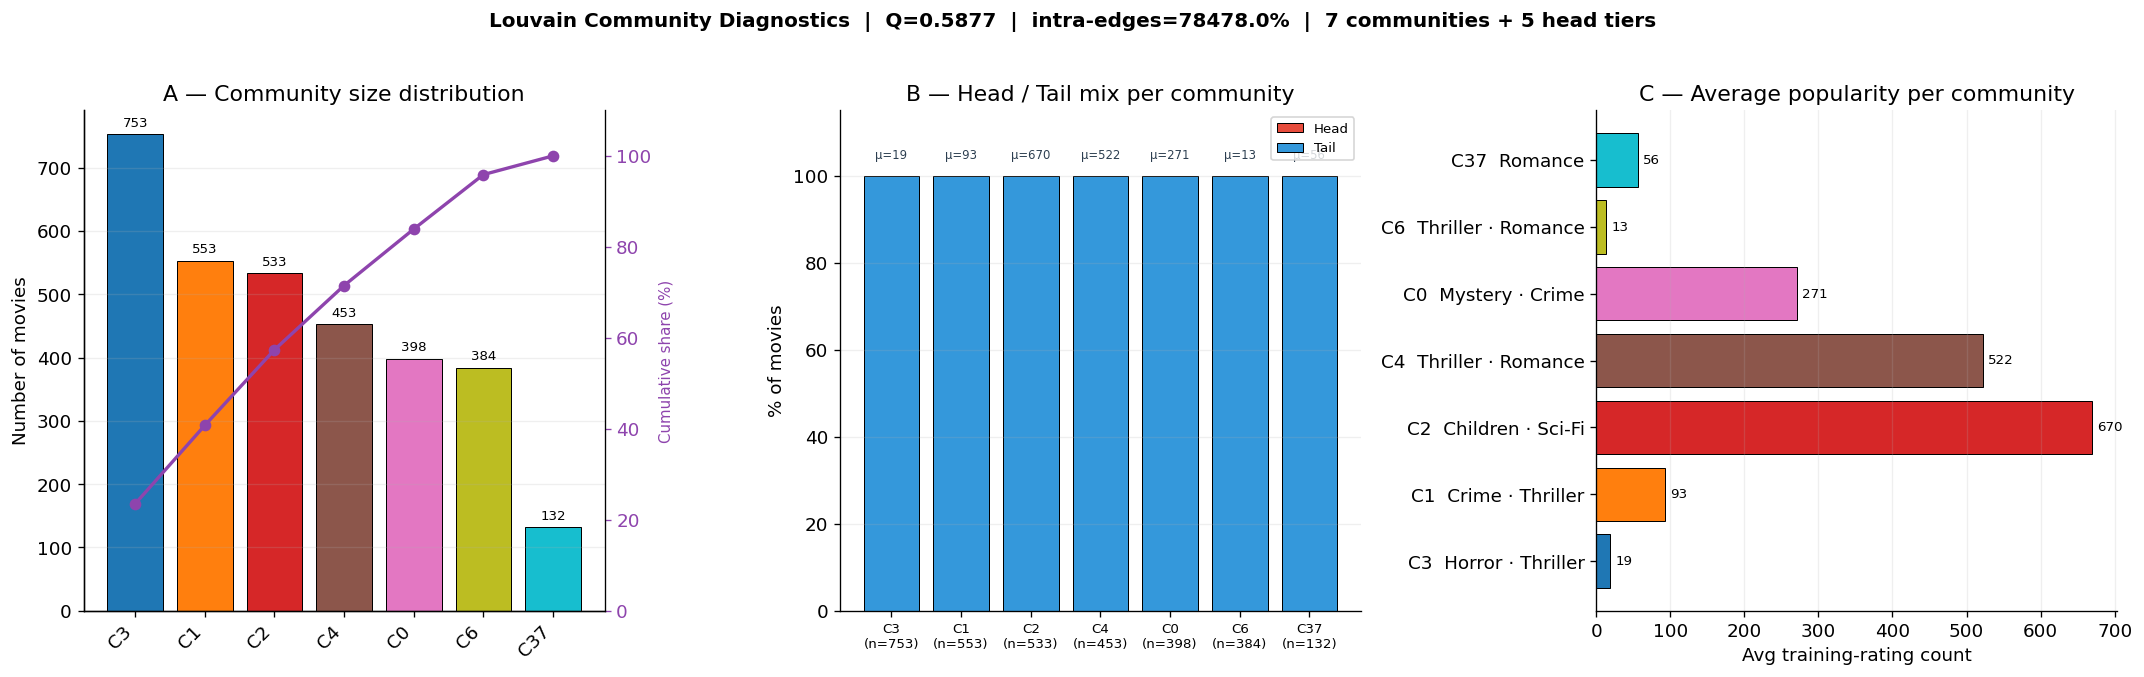

Figure saved.


In [10]:
# 4.2 — Community structure diagnostic plots
comm_sizes_current = Counter(movie_community.values())
louvain_comm_sizes = {c: s for c, s in comm_sizes_current.items()
                      if not str(c).startswith('H')}
louvain_df = pd.DataFrame(
    [{'community': c, 'size': s} for c, s in louvain_comm_sizes.items()]
).sort_values('size', ascending=False).reset_index(drop=True)

all_louvain_comms = louvain_df['community'].tolist()
cmap          = plt.cm.get_cmap('tab10', max(len(all_louvain_comms), 1))
comm_to_color = {cid: cmap(i) for i, cid in enumerate(all_louvain_comms)}

# Per-community metadata for labels (niche genre: Drama/Comedy excluded)
comm_meta = {}
for c in all_louvain_comms:
    cm      = [m for m, cc in partition_clean.items() if cc == c]
    avg_pop = np.mean([movie_train_counts.get(m, 0) for m in cm])
    gc = Counter()
    for m in cm:
        row = movies[movies.movieId == m]
        if row.empty: continue
        g = row.iloc[0].genres
        if pd.isna(g) or g == '(no genres listed)': continue
        for p in g.split('|'):
            if p not in SKIP_GENRES: gc[p] += 1
    if not gc:
        genre = 'Unknown'
    else:
        total = len(cm)
        qual  = {g: cnt for g, cnt in gc.items() if cnt / total >= 0.1} or gc
        sg    = sorted(qual.items(), key=lambda x: (PRIORITY_RANK.get(x[0], 99), -x[1]))
        genre = ' · '.join(g for g, _ in sg[:2])
    comm_meta[c] = dict(avg_pop=avg_pop, genre=genre, size=len(cm))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
ax_a, ax_b, ax_c = axes

# Panel A: Community size bars
labels_a  = [f'C{c}' for c in louvain_df['community']]
sizes_top = louvain_df['size'].astype(int).tolist()
x = np.arange(len(labels_a))
bars = ax_a.bar(x, sizes_top,
                color=[comm_to_color[c] for c in louvain_df['community']],
                edgecolor='k', linewidth=0.6)
ax_a.set_xticks(x); ax_a.set_xticklabels(labels_a, rotation=45, ha='right')
ax_a.set_ylabel('Number of movies')
ax_a.set_title('A — Community size distribution')
ax_a.grid(axis='y', alpha=0.2)
ax_a.spines[['top','right']].set_visible(False)
for b in bars:
    h = b.get_height()
    ax_a.text(b.get_x()+b.get_width()/2, h + max(sizes_top)*0.01,
              f'{int(h):,}', ha='center', va='bottom', fontsize=8)
ax_a2 = ax_a.twinx()
cum_share = np.cumsum(sizes_top) / max(np.sum(sizes_top), 1)
ax_a2.plot(x, cum_share*100, color='#8e44ad', marker='o', lw=2)
ax_a2.set_ylabel('Cumulative share (%)', color='#8e44ad', fontsize=9)
ax_a2.tick_params(axis='y', colors='#8e44ad')
ax_a2.set_ylim(0, 110); ax_a2.spines[['top']].set_visible(False)

# Panel B: Head/tail composition
h_pcts, t_pcts, labels_b = [], [], []
for c in louvain_df['community']:
    cm  = [m for m, cc in partition_clean.items() if cc == c]
    h   = sum(1 for m in cm if m in head_movies_in_graph)
    tot = max(len(cm), 1)
    h_pcts.append(h/tot*100); t_pcts.append((tot-h)/tot*100)
    labels_b.append(f'C{c}\n(n={louvain_comm_sizes[c]})')
xpos = np.arange(len(labels_b))
ax_b.bar(xpos, h_pcts, label='Head', color=C_HEAD, edgecolor='k', linewidth=0.6)
ax_b.bar(xpos, t_pcts, bottom=h_pcts, label='Tail', color=C_TAIL, edgecolor='k', linewidth=0.6)
ax_b.set_xticks(xpos); ax_b.set_xticklabels(labels_b, fontsize=8)
ax_b.set_ylabel('% of movies')
ax_b.set_title('B — Head / Tail mix per community')
ax_b.legend(fontsize=8); ax_b.set_ylim(0, 115)
ax_b.spines[['top','right']].set_visible(False); ax_b.grid(axis='y', alpha=0.2)
for i, c in enumerate(louvain_df['community']):
    ax_b.text(i, 104, f'μ={comm_meta[c]["avg_pop"]:.0f}',
              ha='center', fontsize=7, color='#2c3e50')

# Panel C: Average popularity per community
avg_pops = [comm_meta[c]['avg_pop'] for c in louvain_df['community']]
bars_c = ax_c.barh([f'C{c}  {comm_meta[c]["genre"][:22]}'
                    for c in louvain_df['community']],
                   avg_pops,
                   color=[comm_to_color[c] for c in louvain_df['community']],
                   edgecolor='k', linewidth=0.6)
ax_c.set_xlabel('Avg training-rating count')
ax_c.set_title('C — Average popularity per community')
ax_c.grid(axis='x', alpha=0.2); ax_c.spines[['top','right']].set_visible(False)
for bar, val in zip(bars_c, avg_pops):
    ax_c.text(val + max(avg_pops)*0.01, bar.get_y()+bar.get_height()/2,
              f'{val:.0f}', va='center', fontsize=8)

plt.suptitle(
    f'Louvain Community Diagnostics  |  Q={louvain_modularity:.4f}  |  '
    f'intra-edges={intra/total:.1%}  |  '
    f'{n_communities} communities + {N_HEAD_TIERS} head tiers',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'louvain_community_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## Section 5 — Summary

### What to look for

| Check | Good sign | Concern |
|-------|-----------|--------|
| Modularity Q | > 0.30 → well-separated | < 0.15 → weak structure |
| Intra-community edges | > 80% → tight clusters | < 60% → noisy graph |
| Genre coherence | Each community has a dominant genre | Mixed equally → communities are arbitrary |
| Community sizes | Reasonably balanced | One community with 90%+ of nodes |

### Connection to `main_notebook.ipynb`

The `movie_community` dictionary built in Section 3 is used directly by the greedy re-ranking algorithm in Section 5 of main_notebook. Parameters set here (`JACCARD_THRESH=0.09`, `MIN_CO_RATINGS=5`, `LOUVAIN_RES=1.0`, `MIN_COMM_SIZE=20`) are the same ones used in the final evaluation.

If you want to try different parameters, change the config in Section 1 and re-run from Section 2.